In [ ]:

# H1: Properties located at specific geographic coordinates (latitude and longitude) 
#     that are NOT waterfront are more likely to provide Smaller lot sizes. 
# #### Turned out to be True!!!!


# H2: Properties that are characterized by either having at least 
#     four bathrooms or having a larger living area than neighboring 
#     properties have relatively higher grades.
# #### Turned out to be NOT NECESSARILY TRUE!!!!


# H3: Properties that are historically older but in good condition are more likely to be 
#     in original format and not been renovated, preserving their original architectural character.
# #### Turned out to be COMPLETELY TRUE!!!!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# read the data frame
df = pd.read_csv('data/df_cleaned.csv')

In [3]:
# Setting thresholds
lot_thre = df['sqft_lot'].quantile(0.95)

historic_thre = 70

condition_thre = np.median(df['condition'].unique())

Text(0.5, 1.0, 'Big Lot Distribution by Waterfront')

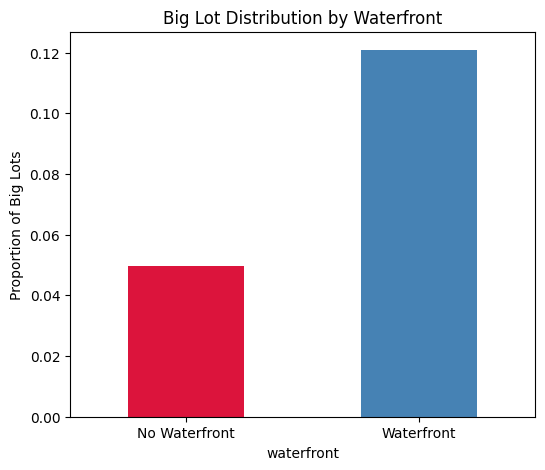

In [6]:
# Hypo1 Flags 
df['is_big_lot'] = df['sqft_lot'] > lot_thre

# Plot
h1_plot = df.groupby('waterfront')['is_big_lot'].mean()

plt.figure(figsize=(6, 5))
h1_plot.plot(kind='bar', color=['crimson', 'steelblue'])

plt.xticks([0, 1], ['No Waterfront', 'Waterfront'], rotation=0)
plt.ylabel("Proportion of Big Lots")
plt.title("Big Lot Distribution by Waterfront")

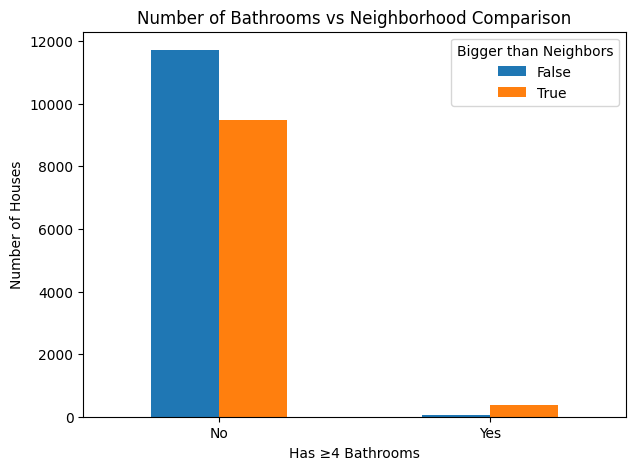

In [10]:
# Hypo2 Flags
df['4_bath'] = df['bathrooms'] >= 4
df['is_locally_dominant'] = df['sqft_living'] > df['sqft_living15']

# Combined condition
df['meets_h2'] = df['4_bath'] | df['is_locally_dominant']

# Plot
h2_ct = pd.crosstab(df['4_bath'], df['is_locally_dominant'])

h2_ct.plot(kind='bar', figsize=(7, 5))

plt.xlabel("Has ≥4 Bathrooms")
plt.ylabel("Number of Houses")
plt.title("Number of Bathrooms vs Neighborhood Comparison")

plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.legend(title="Bigger than Neighbors")

plt.show()

Text(0, 0.5, 'Number of Houses Meeting Hypo 2 Conditions')

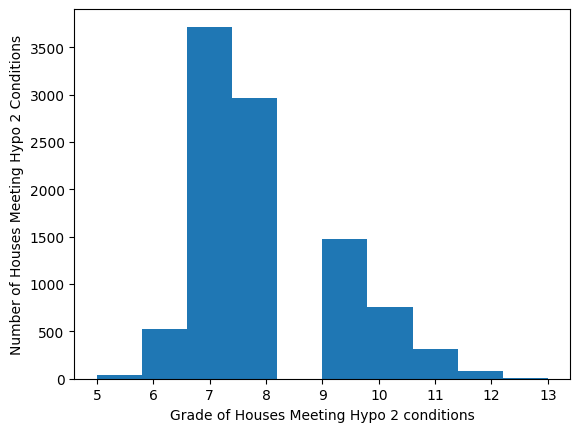

In [12]:
plt.hist(df[df['meets_h2']]['grade'])
plt.xlabel("Grade of Houses Meeting Hypo 2 conditions")
plt.ylabel("Number of Houses Meeting Hypo 2 Conditions")

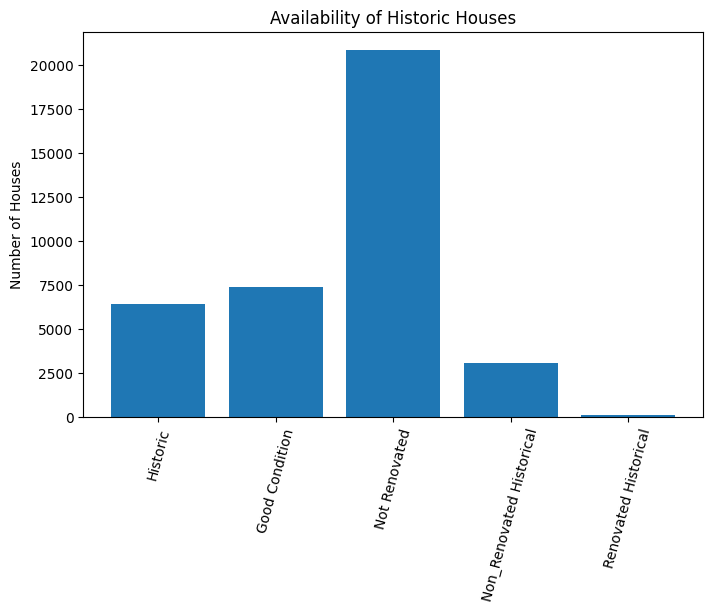

In [11]:

# Hypo3 Flags
df['is_historic'] = df['house_age'] > historic_thre
df['is_good_condition'] = df['condition'] > condition_thre
df['is_not_renovated'] = df['if_renovated'] == 0
df['is_renovated'] = df['if_renovated'] == 1

df['histo_orig'] = (
    df['is_historic'] &
    df['is_good_condition'] &
    df['is_not_renovated']
)

df['histo_reno'] = (
    df['is_historic'] &
    df['is_good_condition'] &
    df['is_renovated']
)


# Plot
h3_counts = [
    df['is_historic'].sum(),
    df['is_good_condition'].sum(),
    df['is_not_renovated'].sum(),
    df['histo_orig'].sum(),
    df['histo_reno'].sum(),
]

labels = [
    "Historic",
    "Good Condition",
    "Not Renovated",
    "Non_Renovated Historical",
    "Renovated Historical"
]

plt.figure(figsize=(8, 5))
plt.bar(labels, h3_counts)

plt.ylabel("Number of Houses")
plt.title("Availability of Historic Houses")
plt.xticks(rotation=75)

plt.show()